# Install package

In [ ]:
# !nvidia-smi

In [ ]:
!pip install mat4py
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from scipy.io import loadmat
from scipy.io import savemat
import os
os.chdir('/content/drive/My Drive')

In [ ]:
!pip install gym tensorflow matplotlib numpy mat4py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 743.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 150.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827727 sha256=3d1a3f48dc56c2c294944cbaf33062388c866cbf929d973ad91a537d6a6fb834
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32

In [ ]:
import collections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gym
import tensorflow as tf
import os
import random
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import RNN
import tensorflow.keras.backend as K
import sys
from gym import spaces
from gym.utils import seeding
import copy
from mat4py import loadmat
from tensorflow.keras import layers
from tensorflow import keras
import time
np.set_printoptions(precision=16)

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
tf.keras.backend.set_floatx('float64')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# Environment Setup

In [ ]:
# Transient Frequency Control Porblem Environment
class Transient_Frequency(gym.Env):
    def  __init__(self,M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state):
        self.param_gamma=1
        self.M=M
        self.Minv=Minv
        self.F=F
        self.D=D
        self.R=R
        self.Rinv=Rinv
        self.Tm=Tm
        self.Tminv=Tminv
        self.Pl=Pl
        self.delta_t=delta_t
        self.dim_state=dim_state
        self.viewer = None
        self.state=[]

        # self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                  np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*1*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                            np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                   np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.diag(Tminv.reshape(dim_state,)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                       np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                         np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*3*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                   np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                                          np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                              np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.power_injection_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.input_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.identity((dim_state))))

        self.diff_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        # self.gen_input_mat = np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), -delta_t*np.identity((dim_state)), np.zeros((dim_state,dim_state))))

        self.select_omega = np.vstack((np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_theta = np.vstack((np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pm = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pg = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state))))

        self.select_E = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)),np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state)))


    def step(self,action,Pl_change):

        theta_difference_sum =np.sum(np.sin((np.transpose(self.state@self.select_theta)@np.ones((1,dim_state)) - np.ones((dim_state,1))@(self.state@self.select_theta)))*F,axis=1)

        self.state=copy.deepcopy(self.state@self.state_transfer + (Pl+Pl_change)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat)
        return self.state

    def set_state(self, state_input):
        self.state=state_input

In [ ]:
# Simulation data load from IEEE 39-bus system

data = loadmat('/content/drive/MyDrive/Colab Notebooks/IEEE_39bus_Kron.mat')

K_EN=data['Kron_39bus']['K']
K_EN=np.asarray(K_EN, dtype=np.float64)

H=data['Kron_39bus']['H']
H=np.asarray(H, dtype=np.float64)

Damp=data['Kron_39bus']['D']
Damp=np.asarray(Damp, dtype=np.float64)

omega_R=data['Kron_39bus']['omega_R']

# A_EN=data['Kron_39bus']['A']
# A_EN=np.asarray(A_EN, dtype=np.float64)

# gamma=data['Kron_39bus']['gamma']
# gamma=np.asarray(gamma, dtype=np.float64)


# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-adjacency-matrix.mat')
# C=data['D']
# C=np.asarray(C, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-power-initial-balanced.mat')
# Power_initial=data['power_initial']
# Power_initial=np.asarray(Power_initial, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-generator.mat')
# Rotational_inertial_generator=data['rotational_inertial_generator']
# Rotational_inertial_generator=np.asarray(Rotational_inertial_generator, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-load.mat')
# Rotational_inertial_load=data['rotational_inertial_load']
# Rotational_inertial_load=np.asarray(Rotational_inertial_load, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-susceptance-matrix.mat')
# B=data['D_reactance']
# B=np.asarray(B, dtype=np.float64)

In [ ]:
dim_state=10 #dimension of action space
dim_state_whole=5*dim_state #dimension of state space
action_units=dim_state
delta_t=0.01
M=H.reshape(dim_state)*2/omega_R*2*np.pi
# M[9] = .1*M[9]
Minv = 1/M
D=np.zeros(dim_state,dtype=np.float64)
D[0]=2*590/100
D[1:8]=2*865/100
D[8:10]=2*911/100
D=D/omega_R*2*np.pi
R=0.1*np.ones((1,dim_state),dtype=np.float64) #0.5
F=K_EN
Tm=7*np.ones((1,dim_state),dtype=np.float64) #7
# Tm[:,9] = 1
Rinv = 1/R
Tminv = 1/Tm
Power_initial=np.array([[0.19983394, 0.25653884, 0.25191885, 0.10242008, 0.34510365,
         -0.23206371,  -0.4404325 ,  -0.5896664 ,  -0.26257738, 0.36892462]],dtype=np.float32)
syn_frequency=-np.sum(Power_initial)/(np.sum(D) + np.sum(1/R))
Pl=copy.deepcopy(Power_initial)
Pl_nominal=copy.deepcopy(Pl)
Penalty_action= 0.2
Penalty_E= 2
equilibrium_init=np.array([[ -0.05420687, -0.07780334, -0.07351729, -0.05827823, -0.09359571,
        -0.02447385, -0.00783582,  0.00259523, -0.0162409 , -0.06477749,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.]],dtype=np.float64)
env = Transient_Frequency(M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state)

# Init Simulation

In [ ]:
E_upper = .3*np.ones((1,dim_state))
E_lower = -E_upper
Pe_upper = np.abs(Power_initial)
Pe_lower = -Pe_upper

# #Linear Controller

boundary_upper=0.8*E_upper
boundary_lower=0.8*E_lower

def get_inside_bound(input,boundary_upper,boundary_lower):
    zero = tf.zeros_like(input, dtype=tf.float64)
    one = tf.ones_like(input, dtype=tf.float64)
    scale_factor_upper = tf.ones_like(input)
    scale_factor_lower = tf.ones_like(input)
    scale_factor_upper = tf.where(input <= boundary_upper, one, zero)
    scale_factor_lower = tf.where(input >= boundary_lower, one, zero)
    return scale_factor_upper*scale_factor_lower

def get_below_bound(input,boundary_lower):
    zero = tf.zeros_like(input, dtype=np.float64)
    one = tf.ones_like(input, dtype=np.float64)
    scale_factor = tf.where(input < boundary_lower, one, zero)
    return scale_factor

def get_beyond_bound(input,boundary_upper):
    zero = tf.zeros_like(input, dtype=tf.float64)
    one = tf.ones_like(input, dtype=tf.float64)
    scale_factor = tf.where(input > boundary_lower, one, zero)
    return scale_factor

slope = 0

def Action_Linear(state,env):

    states_controlled = state@env.select_omega
    states_E = state@env.select_E

    f = slope*(states_controlled)
    upper_barrier = (E_upper - states_E)/(E_upper - boundary_upper)
    lower_barrier = (states_E - E_lower)/(boundary_lower - E_lower)

    action_tempp = get_inside_bound(states_E,boundary_upper,boundary_lower)*f + get_beyond_bound(states_E,boundary_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,boundary_lower)*tf.math.maximum(f,lower_barrier*f)
    action_temp = tf.math.minimum(Pe_upper,action_tempp)
    action = tf.math.maximum(Pe_lower,action_temp)

    nonlinear = slope*(states_controlled)

    return nonlinear, action

#Linear case

<>:122: SyntaxWarning: invalid escape sequence '\o'
<>:132: SyntaxWarning: invalid escape sequence '\T'
<>:122: SyntaxWarning: invalid escape sequence '\o'
<>:132: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipython-input-3293658757.py:122: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$ (Hz)', fontsize=14)
/tmp/ipython-input-3293658757.py:132: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel('$\Theta$ (rad)', fontsize=14)


array([[-0.05420687        , -0.07780334        , -0.07351729        ,
        -0.05827823        , -0.09359571        , -0.02447385        ,
        -0.00783582        ,  0.00259523        , -0.0162409         ,
        -0.06477749        ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                , -0.0578678475912629,  0.1272557351391867,
      

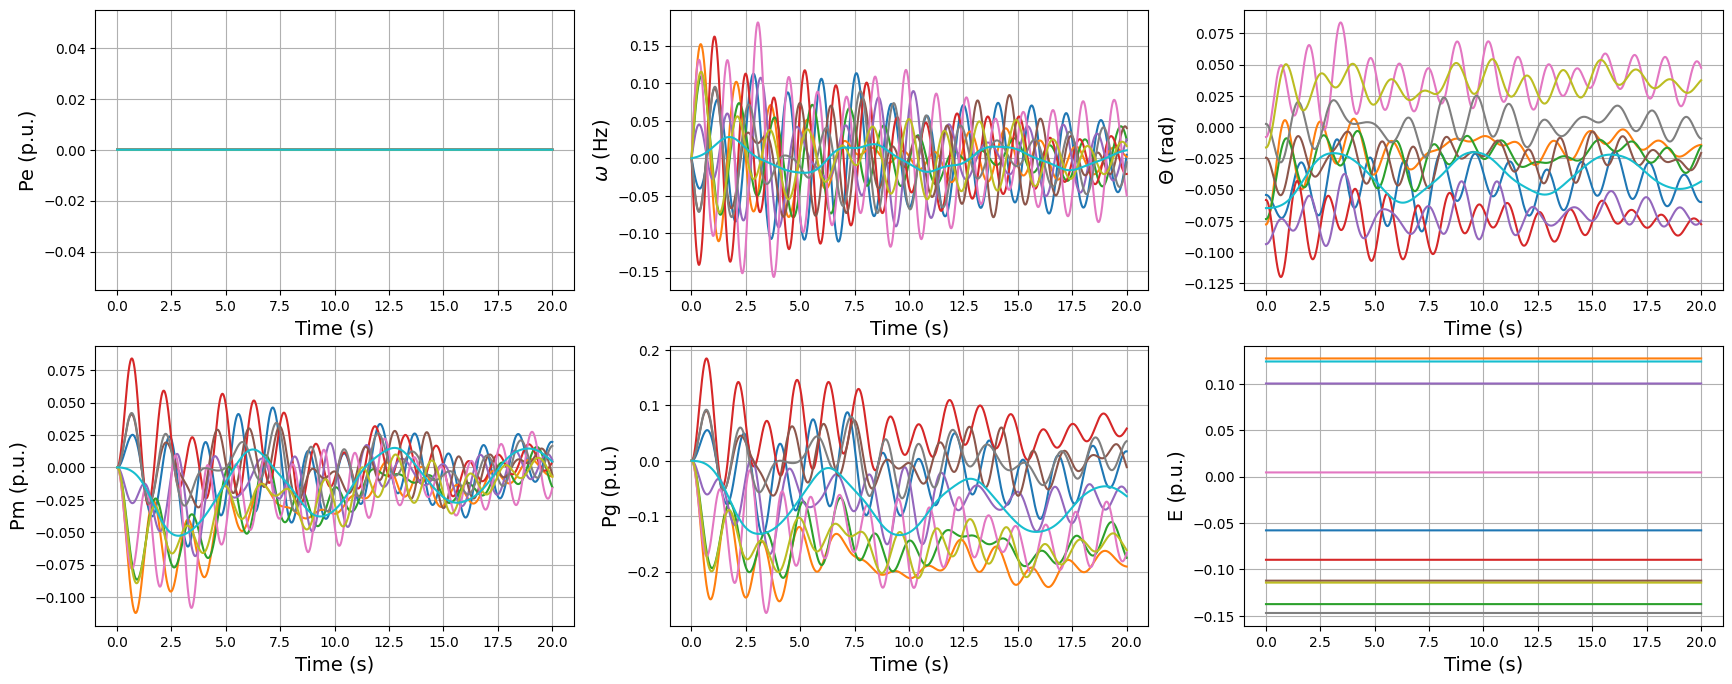

In [ ]:
# Plot the trajectory to visulize the performance of control

Trajectory_Linear_omega=[]
Trajectory_Linear_omega_true=[]
Trajectory_Linear_theta=[]
Trajectory_Linear_Pm=[]
Trajectory_Linear_Pg=[]
Trajectory_Linear_E=[]

# theta_rnn_init_bound=0.05
# omega_rnn_init_bound=0.1 #in Hz
# Pm_rnn_init_bound=0
# E_rnn_init_bound=0*E_upper

theta_rnn_init_bound=0.05*0
omega_rnn_init_bound=0.1*0 #in Hz
Pm_rnn_init_bound=0.05*0
Pg_rnn_init_bound=0
E_rnn_init_bound= .5*E_upper

s_concate = np.zeros((1,5*dim_state))

initial_state1= np.random.uniform(-theta_rnn_init_bound,theta_rnn_init_bound,(1,dim_state))
initial_state2= np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(1,dim_state))
initial_state3= np.random.uniform(-Pm_rnn_init_bound,Pm_rnn_init_bound,(1,dim_state))
initial_state4= np.random.uniform(-Pg_rnn_init_bound,Pg_rnn_init_bound,(1,dim_state))
initial_state5= np.random.uniform(-E_rnn_init_bound,E_rnn_init_bound,(1,dim_state))
s_concate=np.hstack((initial_state1,initial_state2,initial_state3,initial_state4,initial_state5)).astype(np.float64)

init_state=s_concate + equilibrium_init

#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_theta = s@env.select_theta
s_record_all_Pm = s@env.select_Pm
s_record_all_Pg = s@env.select_Pg
s_record_all_E = s@env.select_E
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))

env.set_state(s)
Trajectory_Linear_omega.append(s_record_all_omega)
Trajectory_Linear_theta.append(s_record_all_theta)
Trajectory_Linear_omega_true.append(s_record_all_omega_true)
Trajectory_Linear_Pm.append(s_record_all_Pm)
Trajectory_Linear_Pg.append(s_record_all_Pg)
Trajectory_Linear_E.append(s_record_all_E)

Test_time=20
Train_time=5

SimulationLength=int(Test_time/delta_t)
Record_u_Linear=[]
Record_e_Linear=[]
Loss_Linear=0

# generator_loss_node = np.arange(dim_state)  ## -1
Pl_change_test = np.zeros((1,dim_state))

# generator_loss_start_time = 0
# generator_loss_period = 10

# Pl_change_test = 1*np.random.uniform(-1,1,dim_state)  # np.random.uniform(-1,1,4)*2 #-Pl_nominal[0,generator_loss_node]

Pl_change_test = np.array([[ 0.2340710641071226, -0.5867602762801327, -0.4561132718248471,
        0.6271401105973777, -0.1808982288146022,  0.3780068723952434,
       -0.5433232759085382,  0.2702496806181285, -0.4870327862385655,
       -0.1166459469537584]], dtype=np.float64)

# Pl_change_test = 0.3*np.array([[-0.8905491129973098, -0.4424022836421031, -0.945952470869504,
#   -0.4609707306414945,  0.8244178919743579,  0.2138969034820994,
#   -0.3140688381736034, -0.8510438994530267,  0.8778295889243362,
#    0.2575727076764531]],dtype=np.float64)

for i in range(SimulationLength):

    e,u=Action_Linear(s,env)
    next_s= env.step(u,Pl_change_test)
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_theta = s@env.select_theta
    s_record_all_Pm = s@env.select_Pm
    s_record_all_Pg = s@env.select_Pg
    s_record_all_E = s@env.select_E
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))
    Trajectory_Linear_omega.append(s_record_all_omega)
    Trajectory_Linear_theta.append(s_record_all_theta)
    Trajectory_Linear_omega_true.append(s_record_all_omega_true)
    Trajectory_Linear_Pm.append(s_record_all_Pm)
    Trajectory_Linear_Pg.append(s_record_all_Pg)
    Trajectory_Linear_E.append(s_record_all_E)
    Record_e_Linear.append(e)
    Record_u_Linear.append(u)

Trajectory_Linear_omega=np.squeeze(np.asarray(Trajectory_Linear_omega))
Trajectory_Linear_theta=np.squeeze(np.asarray(Trajectory_Linear_theta))
Trajectory_Linear_Pm=np.squeeze(np.asarray(Trajectory_Linear_Pm))
Trajectory_Linear_Pg=np.squeeze(np.asarray(Trajectory_Linear_Pg))
Trajectory_Linear_E=np.squeeze(np.asarray(Trajectory_Linear_E))
Trajectory_Linear_omega_true=np.squeeze(np.asarray(Trajectory_Linear_omega_true))
Record_u_Linear=np.squeeze(np.asarray(Record_u_Linear))
Record_e_Linear=np.squeeze(np.asarray(Record_e_Linear))

plt.figure(figsize=(21,8), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(2,3,1)

plt.plot(TimeRecord,Record_u_Linear)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pe (p.u.)', fontsize=14)


plt.subplot(2,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_omega)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (Hz)', fontsize=14)


plt.subplot(2,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_theta)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\Theta$ (rad)', fontsize=14)


plt.subplot(2,3,4)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_Pm)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pm (p.u.)', fontsize=14)

plt.subplot(2,3,5)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_Pg)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pg (p.u.)', fontsize=14)

plt.subplot(2,3,6)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_E)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('E (p.u.)', fontsize=14)

init_state

In [ ]:
Penalty_action*np.sum(np.power(Record_u_Linear,2))/(Test_time/delta_t) + np.sum(np.max(np.abs(Trajectory_Linear_omega),0)) + Penalty_E*np.sum(np.power(Trajectory_Linear_E[int(Test_time/delta_t-1),:],2))

np.float64(1.3952971772651375)

In [ ]:
Penalty_action*np.sum(np.power(Record_u_Linear,2))/(Test_time/delta_t)

np.float64(0.0)

In [ ]:
np.sum(np.max(np.abs(Trajectory_Linear_omega),0))

np.float64(1.1573010813214355)

In [ ]:
Penalty_E*np.sum(np.power(Trajectory_Linear_E[int(Test_time/delta_t-1),:],2),0)

np.float64(0.23799609594370189)

# RNN

In [ ]:
# RNN Cell to integrate state transition dynamics

class MinimalRNNCell(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=np.float64)[None], [batchsize, 1, 1])
        self.weight_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.bias_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell, self).__init__(**kwargs)

    def build(self, input_shape):

        self.ke_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='ke_temp')

        self.w_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w')

        self.b_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.5),
            name='b')

        self.d = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='d')

        self.built = True

    def call(self, inputs, states):

        # change of power injection
        global count_num

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)

        # stacked ReLU structure to represent control network

        ke_upper = (Pe_upper - Pe_lower)/(E_upper - E_lower)

        ke_temp = tf.math.minimum(tf.math.abs(self.ke_temp),2*D.reshape(self.action_units,))

        ke = tf.math.minimum(ke_temp,ke_upper)

        slope_upper = (ke + tf.sqrt(2*ke*D.reshape(self.action_units,)))/ke
        slope_lower = (ke - tf.sqrt(2*ke*D.reshape(self.action_units,)))/ke

        slope_upper_mat = K.dot(slope_upper.reshape(self.action_units,1),tf.ones((1,self.internal_units),dtype=tf.float64))
        slope_lower_mat = K.dot(slope_lower.reshape(self.action_units,1),tf.ones((1,self.internal_units),dtype=tf.float64))

        w_temp = tf.math.maximum(tf.math.minimum(self.w_temp,slope_upper_mat),slope_lower_mat)

        w=K.dot(w_temp,self.weight_recover)
        b=tf.sort(self.b_temp,axis=-1,direction='DESCENDING')
        d=self.d

        nonlinear_temp = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b)*w,axis=2) + d

        nonlinear_upper = tf.math.minimum(E_lower + Pe_upper/ke, E_upper)
        nonlinear_lower = tf.math.maximum(E_upper + Pe_lower/ke, E_lower)
        nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_temp,nonlinear_lower),nonlinear_upper)

        action = ke*(nonlinear - K.dot(prev_output,self.select_E))

        # integrate the state transition dynamics
        theta_difference_sum = K.sum((tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        count_num+=1
        if count_num == T-1:
          print("One Episode Ended")
          count_num=0

        return [frequency,action,E,nonlinear], [new_state]

class MinimalRNNCell_New(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=np.float64)[None], [batchsize, 1, 1])
        self.w_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.b_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell_New, self).__init__(**kwargs)

    def build(self, input_shape):

        self.w_plus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            # initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w_plus_temp')

        self.b_plus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            # initializer='uniform',
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_plus_temp')
        self.w_minus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            # initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w_minus_temp')

        self.b_minus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            # initializer='uniform',
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_minus_temp')

        self.thr_upper_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='thr_upper_temp')

        self.thr_lower_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='thr_lower_temp')

        self.built = True

    def call(self, inputs, states):

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)
        states_E = K.dot(prev_output,self.select_E)

        # stacked ReLU structure to represent control network

        w_plus_temp=tf.math.abs(self.w_plus_temp0)
        b_plus_temp=tf.math.abs(self.b_plus_temp0)
        w_minus_temp=tf.math.abs(self.w_minus_temp0)
        b_minus_temp=tf.math.abs(self.b_minus_temp0)
        w_plus=K.dot(w_plus_temp,self.w_recover)
        b_plus=K.dot(-b_plus_temp,self.b_recover)
        w_minus=K.dot(-w_minus_temp,self.w_recover)
        b_minus=K.dot(-b_minus_temp,self.b_recover)

        thr_lower = K.sigmoid(self.thr_lower_temp)
        thr_upper = K.sigmoid(self.thr_upper_temp)

        nonlinear_plus=K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b_plus)\
                        *w_plus,axis=2)   #gamma
        nonlinear_minus=K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b_minus)\
                        *w_minus,axis=2)

        f = (nonlinear_plus + nonlinear_minus)

        boundary_upper=thr_upper*E_upper
        boundary_lower=thr_lower*E_lower

        upper_barrier = (E_upper - states_E)/(E_upper - thr_upper*E_upper)
        lower_barrier = (states_E - E_lower)/(thr_lower*E_lower - E_lower)

        action_nonconstrain = get_inside_bound(states_E,thr_upper*E_upper,thr_upper*E_upper)*f + get_beyond_bound(states_E,thr_upper*E_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,thr_lower*E_lower)*tf.math.maximum(f,lower_barrier*f)


        nonlinear = (nonlinear_plus + nonlinear_minus)

        action = tf.math.minimum(tf.math.maximum(action_nonconstrain,Pe_lower),Pe_upper)

        # integrate the state transition dynamics

        theta_difference_sum = K.sum(tf.math.sin(tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        return [frequency,action,E,nonlinear], [new_state]

class MinimalRNNCell_Free(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=tf.float64)[None], [batchsize, 1, 1])
        self.w_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.b_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell_Free, self).__init__(**kwargs)

    def build(self, input_shape):


        self.w_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w')

        self.b_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='b')

        self.d = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='d')

        self.built = True

    def call(self, inputs, states):

        # change of power injection
        global count_num

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)
        states_E = K.dot(prev_output,self.select_E)

        # stacked ReLU structure to represent control network

        w=self.w_temp
        b=self.b_temp
        d=self.d

        nonlinear_nonconstrain = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b)*w,axis=2) + d

        # f = (nonlinear_plus + nonlinear_minus)
        # upper_barrier = (E_upper - states_E)/(E_upper - 0.9*E_upper)
        # lower_barrier = (states_E - E_lower)/(0.9*E_lower - E_lower)

        # action_nonconstrain = get_inside_bound(states_E)*f + get_beyond_bound(states_E)*tf.math.minimum(f,upper_barrier*f) + \
        #                 get_below_bound(states_E)*tf.math.maximum(f,lower_barrier*f)


        nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_nonconstrain,Pe_lower),Pe_upper)


        condition = tf.math.logical_or(tf.math.logical_and(tf.math.less(E_upper , states_E),tf.math.less(tf.zeros((1,dim_state),dtype=tf.float64),nonlinear)), \
                                       tf.math.logical_and(tf.math.less(states_E , E_lower),tf.math.less(nonlinear,tf.zeros((1,dim_state),dtype=tf.float64))))
        action = tf.where(condition, tf.zeros_like(nonlinear), nonlinear)

        # integrate the state transition dynamics

        theta_difference_sum = K.sum((tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        return [frequency,action,E,nonlinear], [new_state]



In [32]:
start = time.time()

episodes = 100
units = dim_state_whole
action_units = dim_state
internal_units = 50
T = 500
Batch_num = 600

# 定义缺失的变量
theta_rnn_init_bound = 0.1
omega_rnn_init_bound = 0.01
Pm_rnn_init_bound = 0.1
Pg_rnn_init_bound = 0.1
E_rnn_init_bound = 0.1

# 创建模型
cell = MinimalRNNCell_New(units, action_units, internal_units, env, Batch_num)
layer = RNN(cell, return_sequences=True, stateful=True)

# 使用正确的输入格式
input_1 = tf.keras.Input(batch_shape=(Batch_num, T, action_units))
outputs = layer(input_1)  # 直接传递，不要用括号
model = tf.keras.models.Model(inputs=input_1, outputs=outputs)
model.compile(optimizer='Adam', loss='mse', metrics=['accuracy'])

# 测试前向传播
try:
    x0 = np.ones((Batch_num, T, action_units), dtype=np.float32)
    y0 = model(x0)
    print("Model forward pass successful!")
except Exception as e:
    print(f"Error in forward pass: {e}")

Loss_record = []
global_step = tf.Variable(0, trainable=False)
learning_rate_initial = 0.1
decayed_lr = tf.keras.optimizers.schedules.ExponentialDecay(
    learning_rate_initial, 20, 0.7, staircase=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=decayed_lr)

PrintUpdate = 1

num_gen_step = 10
Percent_step_change = 1
range_step_change = 1

for i in range(0, episodes):
    # 生成初始状态
    initial_state1 = np.random.uniform(-theta_rnn_init_bound, theta_rnn_init_bound, (Batch_num, dim_state))
    initial_state2 = np.random.uniform(-omega_rnn_init_bound, omega_rnn_init_bound, (Batch_num, dim_state))
    initial_state3 = np.random.uniform(-Pm_rnn_init_bound, Pm_rnn_init_bound, (Batch_num, dim_state))
    initial_state4 = np.random.uniform(-Pg_rnn_init_bound, Pg_rnn_init_bound, (Batch_num, dim_state))
    initial_state5 = np.random.uniform(-E_rnn_init_bound, E_rnn_init_bound, (Batch_num, dim_state))
    initial_state = np.hstack((initial_state1, initial_state2, initial_state3, initial_state4, initial_state5)) + equilibrium_init

    # 生成负载变化
    Pl_change = np.zeros((Batch_num, T, action_units), dtype=np.float32)
    for gen_interupt in range(0, num_gen_step):
        idx_gen_deviation = np.random.randint(0, action_units, Batch_num * Percent_step_change)
        idx_batch_deviation = np.random.randint(0, Batch_num, Batch_num * Percent_step_change)
        step_change = np.random.uniform(-1, 1, (Batch_num * Percent_step_change)) * range_step_change
        for t_interupt in range(0, T):
            Pl_change[idx_batch_deviation, t_interupt, idx_gen_deviation] = step_change

    # 重置状态 - 使用正确的方法
    # 对于 stateful RNN，我们只需要调用 reset_states() 而不传递参数
    # 初始状态会在第一次调用时自动设置
    layer.reset_states()  # 不传递任何参数

    # 或者，如果需要设置自定义初始状态，可以这样做：
    # 注意：这种方法可能不适用于所有版本的TensorFlow
    # layer.states = [tf.convert_to_tensor(initial_state, dtype=tf.float32)]

    with tf.GradientTape() as tape:
        # 确保输入是正确类型
        Pl_change_tensor = tf.convert_to_tensor(Pl_change, dtype=tf.float32)

        # 前向传播
        outputs = model(Pl_change_tensor, training=True)

        # 解析输出
        # 注意：根据你的RNN Cell实现，输出可能有不同的结构
        # 你可能需要根据实际情况调整这行代码
        frequency, action, E, nonlinear = outputs

        # 计算损失
        loss = (Penalty_action * tf.reduce_sum(tf.square(action)) / (Batch_num * T) +
                tf.reduce_sum(tf.reduce_max(tf.abs(frequency), axis=1)) / Batch_num +
                Penalty_E * tf.reduce_sum(tf.square(E[:, -1, :])) / Batch_num)

    # 计算梯度并更新权重
    grads = tape.gradient(loss, model.trainable_variables)
    if grads is not None:
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # 记录损失
    Loss_record.append(loss.numpy())

    # 打印进度
    if i % PrintUpdate == 0:
        print(f'episode {i}, Loss: {loss.numpy()}')
        print(f'episode {i}, Loss_frequency: {tf.reduce_sum(tf.reduce_max(tf.abs(frequency), axis=1)).numpy() / Batch_num}')
        print(f'episode {i}, Loss_action: {Penalty_action * tf.reduce_sum(tf.square(action)).numpy() / (Batch_num * T)}')
        print(f'episode {i}, Loss_E: {Penalty_E * tf.reduce_sum(tf.square(E[:, -1, :])).numpy() / Batch_num}')
        print()

end = time.time()
print(f"Training time: {end - start} seconds")

Model forward pass successful!
episode 0, Loss: 1.3831430167666177
episode 0, Loss_frequency: 1.3826227870358343
episode 0, Loss_action: 2.231959705953385e-05
episode 0, Loss_E: 0.0004979101337239597

episode 1, Loss: 1.272248217276874
episode 1, Loss_frequency: 1.2611794613594771
episode 1, Loss_action: 0.0004229550138541824
episode 1, Loss_E: 0.010645800903542934

episode 2, Loss: 1.1912325597631777
episode 2, Loss_frequency: 1.161595594268021
episode 2, Loss_action: 0.001065812081345595
episode 2, Loss_E: 0.028571153413811008

episode 3, Loss: 1.1733928515567948
episode 3, Loss_frequency: 1.1244772275226134
episode 3, Loss_action: 0.0017612595517782143
episode 3, Loss_E: 0.047154364482403205

episode 4, Loss: 1.1423859663994633
episode 4, Loss_frequency: 1.0939388762003805
episode 4, Loss_action: 0.0021242292651304714
episode 4, Loss_E: 0.046322860933952346

episode 5, Loss: 1.13506921259504
episode 5, Loss_frequency: 1.084681273524426
episode 5, Loss_action: 0.002550501136694126
ep

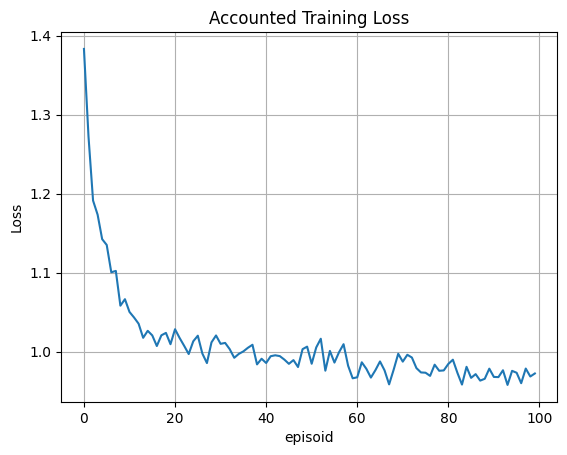

In [33]:
plt.plot(Loss_record)
plt.xlabel('episoid')
plt.ylabel('Loss')
plt.grid()
plt.title('Accounted Training Loss')
# file_name='Loss_ESS_wo_regu.mat'
file_name='Loss_ESS_w_regu.mat'
# file_name='Loss_ESS_Free.mat'
savemat(file_name,{'Loss_record':Loss_record})

In [34]:
from scipy.io import loadmat
from scipy.io import savemat


# w=(model.variables[0]).numpy()
# b=(model.variables[1]).numpy()
# d=(model.variables[2]).numpy()

# file_name='optimal_controllers_Free.mat'
# savemat(file_name,{'w':w,'b':b,'d':d})


w_plus_temp=tf.math.abs(model.variables[0])
b_plus_temp=tf.math.abs(model.variables[1])
w_minus_temp=tf.math.abs(model.variables[2])
b_minus_temp=tf.math.abs(model.variables[3])

w_plus=(K.dot(w_plus_temp,cell.w_recover)).numpy()
b_plus=(K.dot(-b_plus_temp,cell.b_recover)).numpy()
w_minus=(K.dot(-w_minus_temp,cell.w_recover)).numpy()
b_minus=(K.dot(-b_minus_temp,cell.b_recover)).numpy()

thr_upper = (K.sigmoid(model.variables[4])).numpy()
thr_lower = (K.sigmoid(model.variables[5])).numpy()

#file_name='optimal_controllers_ESS_wo_regu.mat'
file_name='optimal_controllers_ESS_w_regu.mat'
savemat(file_name,{'w_plus':w_plus,'b_plus':b_plus,'w_minus':w_minus,'b_minus':b_minus,'thr_upper':thr_upper,'thr_lower':thr_lower})

In [35]:
# print(w_plus)
# print(b_minus)

In [36]:
# print(thr_lower)

In [37]:
# print(thr_upper)

# Simulate

In [38]:
# def Action(state,env):

#     states_controlled = state@cell.select_omega
#     states_E = state@cell.select_E

#     nonlinear_nonconstrain = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b)*w,axis=2) + d

#     nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_nonconstrain, Pe_lower), Pe_upper)

#     condition = tf.math.logical_or(tf.math.logical_and(tf.math.less(E_upper , states_E),tf.math.less(tf.zeros((1,dim_state),dtype=tf.float64),nonlinear)), \
#                                        tf.math.logical_and(tf.math.less(states_E , E_lower),tf.math.less(nonlinear,tf.zeros((1,dim_state),dtype=tf.float64))))

#     action = tf.where(condition, tf.zeros_like(nonlinear), nonlinear)

#     return nonlinear_nonconstrain, action


def Action(state,env):

    states_controlled = state@cell.select_omega
    states_E = state@cell.select_E

    nonlinear_plus=K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b_plus)\
                    *w_plus,axis=2)
    nonlinear_minus=K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b_minus)\
                    *w_minus,axis=2)

    f = (nonlinear_plus + nonlinear_minus)
    upper_barrier = (E_upper - states_E)/(E_upper - thr_upper*E_upper)
    lower_barrier = (states_E - E_lower)/(thr_lower*E_lower - E_lower)

    action_nonconstrain = get_inside_bound(states_E,thr_upper*E_upper,thr_upper*E_upper)*f + get_beyond_bound(states_E,thr_upper*E_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,thr_lower*E_lower)*tf.math.maximum(f,lower_barrier*f)

    action = tf.math.minimum(tf.math.maximum(action_nonconstrain,Pe_lower),Pe_upper)

    nonlinear = nonlinear_plus + nonlinear_minus

    return nonlinear, action

<>:102: SyntaxWarning: invalid escape sequence '\o'
<>:112: SyntaxWarning: invalid escape sequence '\T'
<>:102: SyntaxWarning: invalid escape sequence '\o'
<>:112: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipython-input-3605682000.py:102: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$ (Hz)', fontsize=14)
/tmp/ipython-input-3605682000.py:112: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel('$\Theta$ (rad)', fontsize=14)


array([[-0.05420687        , -0.07780334        , -0.07351729        ,
        -0.05827823        , -0.09359571        , -0.02447385        ,
        -0.00783582        ,  0.00259523        , -0.0162409         ,
        -0.06477749        ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                , -0.0578678475912629,  0.1272557351391867,
      

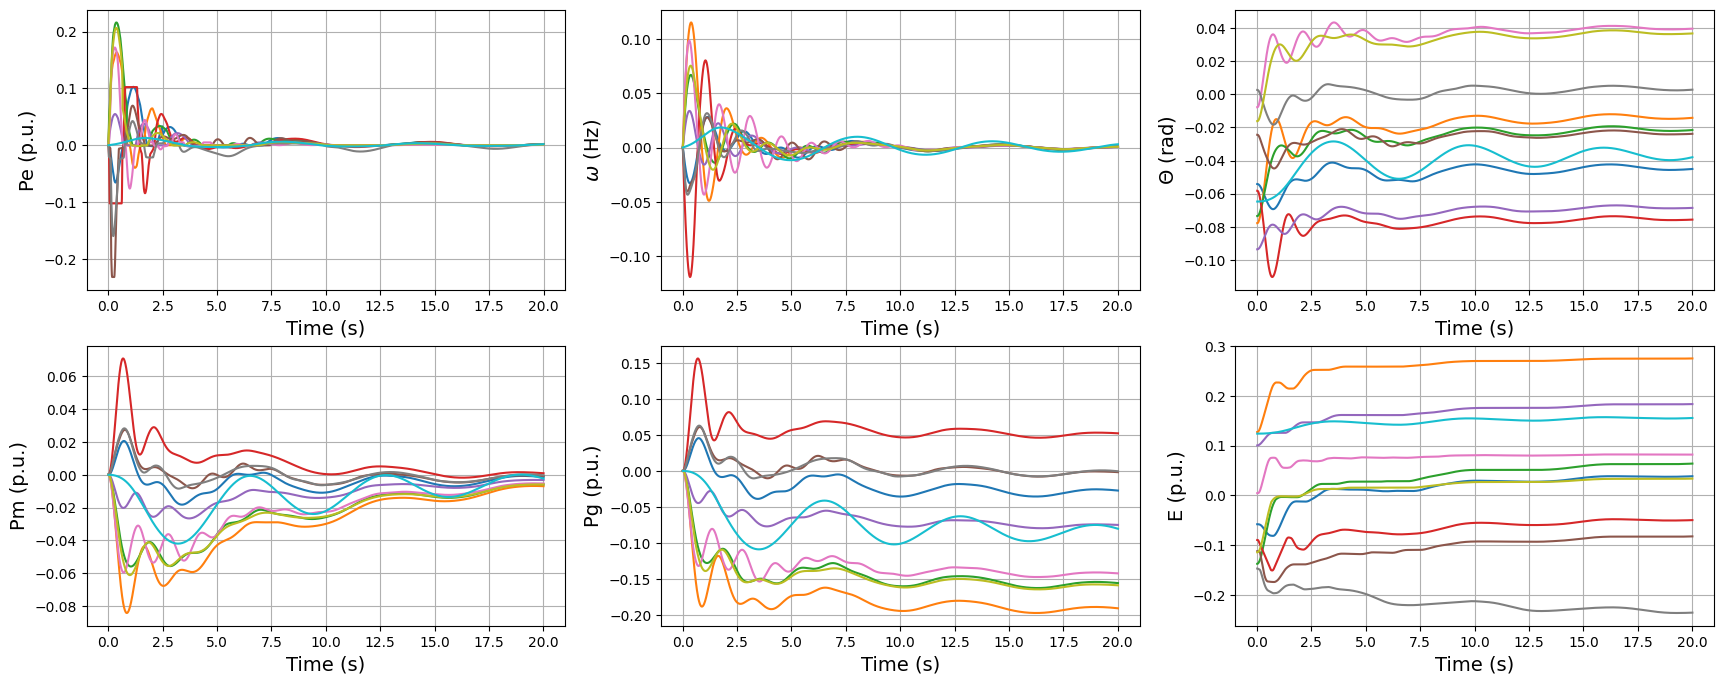

In [39]:
# Plot the trajectory to visulize the performance of control

Trajectory_RNN_omega=[]
Trajectory_RNN_omega_true=[]
Trajectory_RNN_theta=[]
Trajectory_RNN_Pm=[]
Trajectory_RNN_Pg=[]
Trajectory_RNN_E=[]

# theta_rnn_init_bound=0.05
# omega_rnn_init_bound=0.1 #in Hz
# Pm_rnn_init_bound=0.5
# E_rnn_init_bound=E_upper

# s_concate = np.zeros((1,4*dim_state))

# initial_state1= np.random.uniform(-theta_rnn_init_bound,theta_rnn_init_bound,(1,dim_state))
# initial_state2= np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(1,dim_state))
# initial_state3= np.random.uniform(-Pm_rnn_init_bound,Pm_rnn_init_bound,(1,dim_state))
# initial_state4= np.random.uniform(-E_rnn_init_bound,E_rnn_init_bound,(1,dim_state))
# s_concate=np.hstack((initial_state1,initial_state2,initial_state3,initial_state4)).astype(np.float64)

# Pl_change_test[0,generator_loss_node] = np.random.uniform(-1,1,dim_state)  # np.random.uniform(-1,1,4)*2 #-Pl_nominal[0,generator_loss_node]

init_state=s_concate+equilibrium_init
#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_theta = s@env.select_theta
s_record_all_Pm = s@env.select_Pm
s_record_all_Pg = s@env.select_Pg
s_record_all_E = s@env.select_E
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))

env.set_state(s)
Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_theta.append(s_record_all_theta)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_Pm.append(s_record_all_Pm)
Trajectory_RNN_Pg.append(s_record_all_Pg)
Trajectory_RNN_E.append(s_record_all_E)

Test_time=20
SimulationLength=int(Test_time/delta_t)
Record_u_RNN=[]
Record_e_RNN=[]

# generator_loss_start_time = 0
# generator_loss_period = 50

for i in range(SimulationLength):
    # if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
    #   Pl[0,generator_loss_node] = 0
    # else:
    #   Pl[0,generator_loss_node] = Pl_nominal[0,generator_loss_node]
    # Pl[0,generator_loss_node] = 0 #-Pl_nominal[0,generator_loss_node]
    e,u=Action(s,env)
    next_s= env.step(u,Pl_change_test)
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_theta = s@env.select_theta
    s_record_all_Pm = s@env.select_Pm
    s_record_all_Pg = s@env.select_Pg
    s_record_all_E = s@env.select_E
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))
    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_theta.append(s_record_all_theta)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_Pm.append(s_record_all_Pm)
    Trajectory_RNN_Pg.append(s_record_all_Pg)
    Trajectory_RNN_E.append(s_record_all_E)
    Record_e_RNN.append(e)
    Record_u_RNN.append(u)

Trajectory_RNN_omega=np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_theta=np.squeeze(np.asarray(Trajectory_RNN_theta))
Trajectory_RNN_Pm=np.squeeze(np.asarray(Trajectory_RNN_Pm))
Trajectory_RNN_Pg=np.squeeze(np.asarray(Trajectory_RNN_Pg))
Trajectory_RNN_E=np.squeeze(np.asarray(Trajectory_RNN_E))
Trajectory_RNN_omega_true=np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Record_u_RNN=np.squeeze(np.asarray(Record_u_RNN))
Record_e_RNN=np.squeeze(np.asarray(Record_e_RNN))

plt.figure(figsize=(21,8), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(2,3,1)

plt.plot(TimeRecord,Record_u_RNN)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pe (p.u.)', fontsize=14)


plt.subplot(2,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_omega)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (Hz)', fontsize=14)

plt.subplot(2,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord


plt.plot(TimeRecord,Trajectory_RNN_theta)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\Theta$ (rad)', fontsize=14)

plt.subplot(2,3,4)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_Pm)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pm (p.u.)', fontsize=14)

plt.subplot(2,3,5)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_Pg)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pg (p.u.)', fontsize=14)

plt.subplot(2,3,6)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_E)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('E (p.u.)', fontsize=14)

init_state

In [40]:
Penalty_action*np.sum(np.power(Record_u_RNN,2))/(Test_time/delta_t) + np.sum(np.max(np.abs(Trajectory_RNN_omega),0)) + Penalty_E*np.sum(np.power(Trajectory_RNN_E[int(Test_time/delta_t-1),:],2))
#(np.sum(np.power(Record_e_RNN,2))+

np.float64(1.0683558286199513)

In [41]:
Penalty_action*np.sum(np.power(Record_u_RNN,2))/(5/delta_t)

np.float64(0.004658968975048212)

In [42]:
np.sum(np.max(np.abs(Trajectory_RNN_omega),0))

np.float64(0.6444658474185826)

In [43]:
Penalty_E*np.sum(np.power(Trajectory_RNN_E[int(Test_time/delta_t-1),:],2))

np.float64(0.4227252389576065)

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-2705398347.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega_i (Hz)$')
/tmp/ipython-input-2705398347.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$e_i(\omega_i)$ (p.u.)')


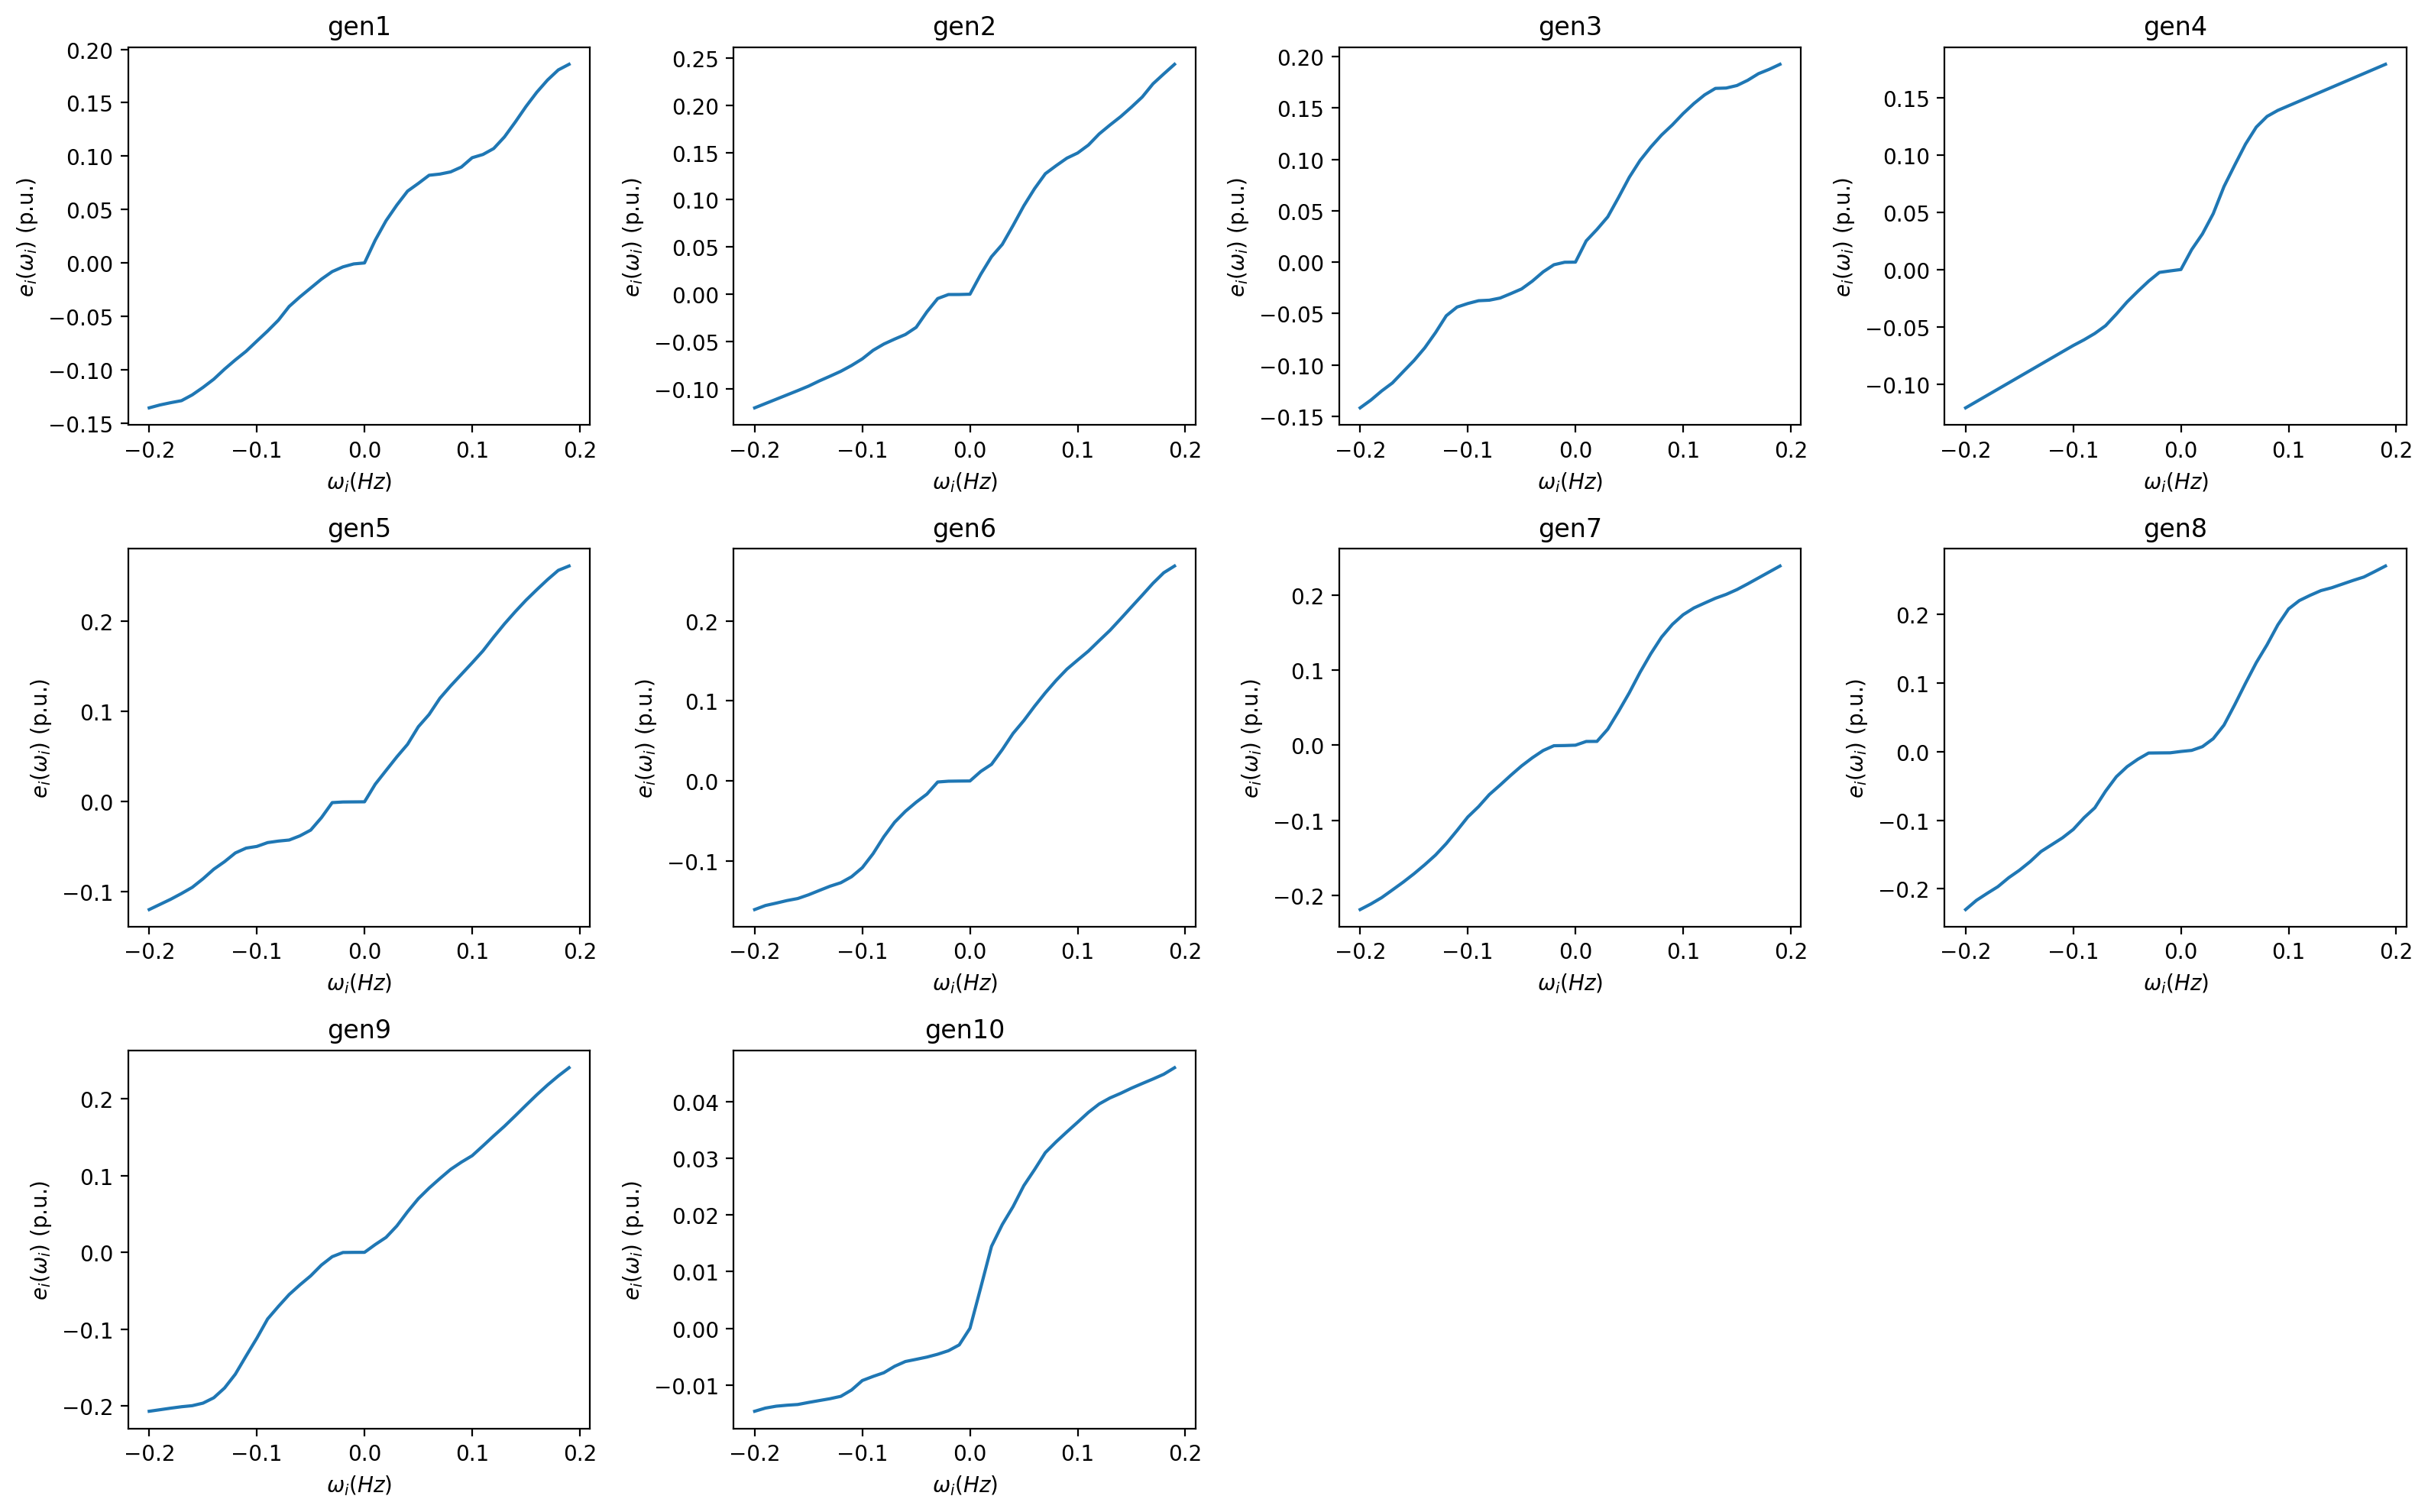

In [44]:
# plot the figures for action in selected buses


state_w=np.arange(-.2,.2,0.01,dtype=np.float32)
# state_d2=np.float32(0.03)
# state_w2=np.float32(0.02)

action_dw=np.zeros(len(state_w))
gen_idx_list=np.arange(dim_state)
fig=plt.figure(figsize=(16,10), dpi=200)
for idx_plot in range(len(gen_idx_list)):
    gen_idx=gen_idx_list[idx_plot]
    for j in range(len(state_w)):
            state_controlled=np.hstack((np.zeros((1,dim_state)),state_w[j]*np.ones((1,dim_state)),np.zeros((1,dim_state)),np.zeros((1,dim_state)),np.zeros((1,dim_state))))
            e,u=Action(state_controlled,env)
            action_dw[j]=e[0][gen_idx]
    plt.subplot(3,4,idx_plot+1)
    plt.plot(state_w,action_dw)
    plt.xlabel('$\omega_i (Hz)$')
    plt.ylabel('$e_i(\omega_i)$ (p.u.)')
    plt.title('gen'+str(gen_idx+1))
    # plt.legend(bbox_to_anchor=(0.98, 0.01), loc='lower right', borderaxespad=0.)
fig.tight_layout()